In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")


# =====================
# CHECK PATH
# =====================
print(os.listdir('/kaggle/input'))

base_path="/kaggle/input/datasets/chauhaiham/datathon-2026/"
print(os.listdir(base_path))


# =====================
# LOAD DATA
# =====================
orders = pd.read_csv(
    base_path+"orders.csv",
    parse_dates=['order_date']
)

order_items = pd.read_csv(
    base_path+"order_items.csv",
    low_memory=False
)

inventory = pd.read_csv(
    base_path+"inventory.csv",
    parse_dates=['snapshot_date']
)

web_traffic = pd.read_csv(
    base_path+"web_traffic.csv",
    parse_dates=['date']
)


# =====================
# PROMOTION BY MONTH
# =====================
order_items['is_promo'] = (
    order_items['promo_id']
    .notna()
    .astype(int)
)

daily_orders = order_items.merge(
    orders[['order_id','order_date']],
    on='order_id',
    how='left'
)

daily_orders['month_year'] = (
    daily_orders['order_date']
    .dt.to_period('M')
)

monthly_promo = (
    daily_orders
    .groupby('month_year')
    .agg(
        total_promo_items=('is_promo','sum')
    )
    .reset_index()
)


# =====================
# INVENTORY BY MONTH
# =====================
inventory['month_year'] = (
    inventory['snapshot_date']
    .dt.to_period('M')
)

monthly_inventory = (
    inventory
    .groupby('month_year')
    .agg(
        total_stockout_days=('stockout_days','sum')
    )
    .reset_index()
)


# =====================
# WEB TRAFFIC BY MONTH
# =====================
web_traffic['month_year'] = (
    web_traffic['date']
    .dt.to_period('M')
)

monthly_traffic = (
    web_traffic
    .groupby('month_year')
    .agg(
        avg_bounce_rate=('bounce_rate','mean'),
        total_sessions=('sessions','sum')
    )
    .reset_index()
)


# =====================
# MASTER TABLE
# =====================
df_master = (
    monthly_promo
    .merge(monthly_inventory,on='month_year')
    .merge(monthly_traffic,on='month_year')
)

df_master['month_year_str'] = (
    df_master['month_year']
    .astype(str)
)

df_plot = df_master.copy()
df_plot = df_plot.sort_values("month_year")
df_plot["month_year_str"] = df_plot["month_year"].astype(str)

print(df_plot.head())


# =====================
# STYLE
# =====================
sns.set_theme(style="whitegrid")

['datasets']
['products.csv', 'sample_submission.csv', 'promotions.csv', 'shipments.csv', 'order_items.csv', 'reviews.csv', 'inventory.csv', 'returns.csv', 'sales.csv', 'orders.csv', 'geography.csv', 'customers.csv', 'payments.csv', 'web_traffic.csv']
  month_year  total_promo_items  total_stockout_days  avg_bounce_rate  \
0    2013-01                 21                  431         0.004530   
1    2013-02               2705                  584         0.004506   
2    2013-03               4573                  587         0.004503   
3    2013-04               4052                  674         0.004672   
4    2013-05                  0                  626         0.004475   

   total_sessions month_year_str  
0          295006        2013-01  
1          416896        2013-02  
2          622174        2013-03  
3          814380        2013-04  
4          816540        2013-05  


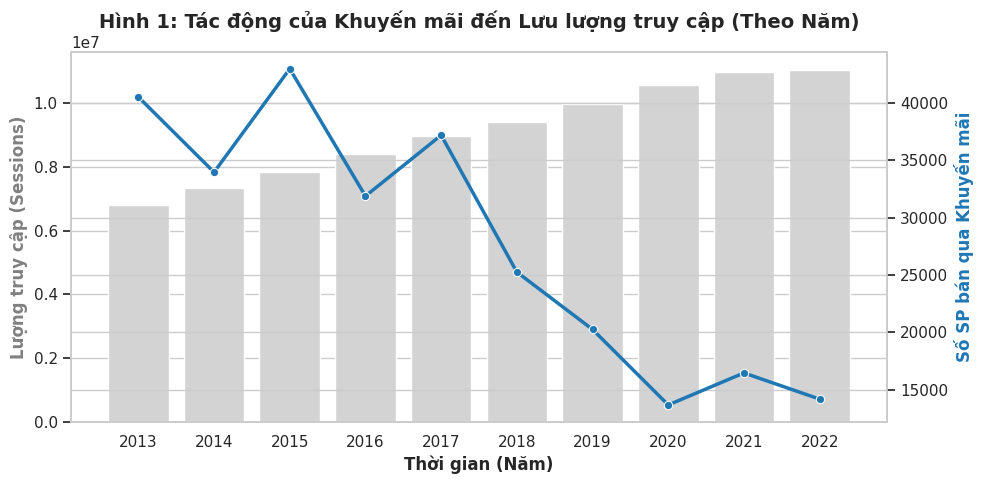

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Xử lý dữ liệu: Tạo cột 'year' và gom nhóm dữ liệu
# Đảm bảo cột được chuyển sang dạng chuỗi (string) trước khi lấy 4 ký tự đầu
df_plot['year'] = df_plot['month_year_str'].astype(str).str[:4] 

# --- SỬA LỖI TẠI ĐÂY ---
# Cách 1 (Khuyên dùng): Chỉ định đích danh các cột cần tính tổng
df_yearly = df_plot.groupby('year')[['total_sessions', 'total_promo_items']].sum().reset_index()

# Cách 2: Bật tính năng chỉ tính tổng các cột dạng số
# df_yearly = df_plot.groupby('year').sum(numeric_only=True).reset_index()
# -----------------------

# 2. Vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(10, 5))

# Trục 1: Cột theo df_yearly
sns.barplot(data=df_yearly, x='year', y='total_sessions', color='lightgray', ax=ax1)
ax1.set_ylabel('Lượng truy cập (Sessions)', color='gray', fontweight='bold')
ax1.set_xlabel('Thời gian (Năm)', fontweight='bold')
ax1.tick_params(axis='x', rotation=0)

# Trục 2: Đường theo df_yearly
ax2 = ax1.twinx()
sns.lineplot(data=df_yearly, x='year', y='total_promo_items', color='tab:blue', marker='o', linewidth=2.5, ax=ax2)
ax2.set_ylabel('Số SP bán qua Khuyến mãi', color='tab:blue', fontweight='bold')

plt.title('Hình 1: Tác động của Khuyến mãi đến Lưu lượng truy cập (Theo Năm)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_traffic_promo_yearly.pdf') 
plt.show()

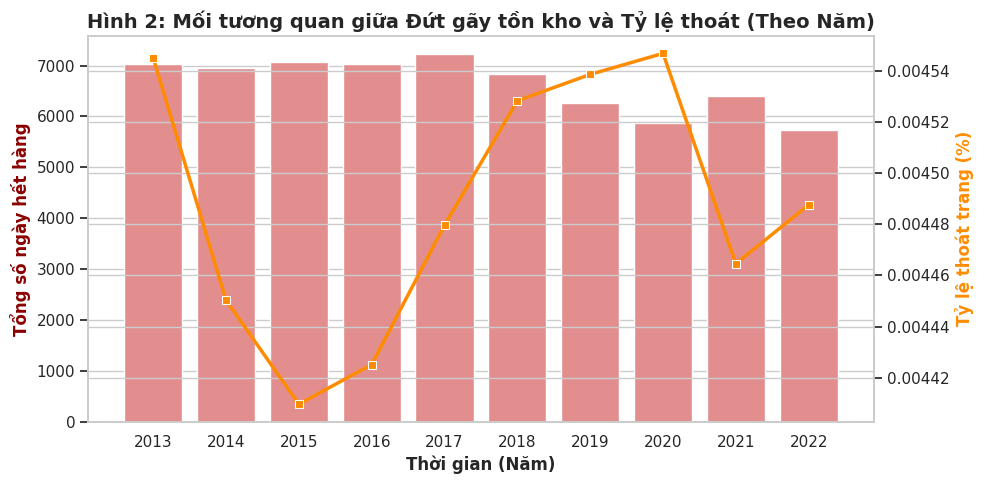

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Xử lý dữ liệu: Tạo cột 'year' và gom nhóm dữ liệu (tránh lỗi TypeError)
df_plot['year'] = df_plot['month_year_str'].astype(str).str[:4] 

# Tính tổng cho số ngày hết hàng và tính trung bình cho tỷ lệ thoát trang
df_yearly = df_plot.groupby('year').agg({
    'total_stockout_days': 'sum',
    'avg_bounce_rate': 'mean'
}).reset_index()

# 2. Vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(10, 5))

# Trục 1: Số ngày hết hàng (Cột đỏ nhạt)
sns.barplot(data=df_yearly, x='year', y='total_stockout_days', color='lightcoral', ax=ax1)
ax1.set_ylabel('Tổng số ngày hết hàng', color='darkred', fontweight='bold')
ax1.set_xlabel('Thời gian (Năm)', fontweight='bold')
ax1.tick_params(axis='x', rotation=0)

# Trục 2: Tỷ lệ thoát trang (Đường cam)
ax2 = ax1.twinx()
sns.lineplot(data=df_yearly, x='year', y='avg_bounce_rate', color='darkorange', marker='s', linewidth=2.5, ax=ax2)
ax2.set_ylabel('Tỷ lệ thoát trang (%)', color='darkorange', fontweight='bold')

plt.title('Hình 2: Mối tương quan giữa Đứt gãy tồn kho và Tỷ lệ thoát (Theo Năm)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_stockout_bounce_yearly.pdf')
plt.show()

In [60]:
import pandas as pd
import plotly.graph_objects as go

# 1. Khai báo đường dẫn Kaggle
base_path = "/kaggle/input/datasets/chauhaiham/datathon-2026/"

# 2. Đọc dữ liệu
df_order_items = pd.read_csv(base_path + 'order_items.csv')
df_products = pd.read_csv(base_path + 'products.csv')
df_returns = pd.read_csv(base_path + 'returns.csv')
df_shipments = pd.read_csv(base_path + 'shipments.csv')

# 3. Tính toán các Dòng tiền
gross_revenue = (df_order_items['quantity'] * df_order_items['unit_price']).sum()
total_discounts = df_order_items['discount_amount'].sum()

df_oi_prod = df_order_items.merge(df_products[['product_id', 'cogs']], on='product_id', how='left')
total_cogs = (df_oi_prod['quantity'] * df_oi_prod['cogs']).sum()

total_returns = df_returns['refund_amount'].sum()
total_shipping = df_shipments['shipping_fee'].sum()

net_profit = gross_revenue - (total_cogs + total_discounts + total_returns + total_shipping)

# 4. Vẽ biểu đồ Thác nước (Waterfall Chart)
fig = go.Figure(go.Waterfall(
    name = "Lợi nhuận",
    orientation = "v",
    # 'relative' là các biến động (tăng/giảm), 'total' là cột tổng kết cuối cùng
    measure = ["relative", "relative", "relative", "relative", "relative", "total"],
    x = ["Tổng Doanh Thu", "Giá Vốn (COGS)", "Khuyến Mãi", "Trả Hàng", "Phí Vận Chuyển", "LỢI NHUẬN RÒNG"],
    textposition = "outside",
    # Format text hiển thị (Chia 1 triệu để số gọn gàng, thêm chữ M phía sau)
    text = [f"+{gross_revenue/1e6:.1f}M", f"-{total_cogs/1e6:.1f}M", f"-{total_discounts/1e6:.1f}M", 
            f"-{total_returns/1e6:.1f}M", f"-{total_shipping/1e6:.1f}M", f"{net_profit/1e6:.1f}M"],
    y = [gross_revenue, -total_cogs, -total_discounts, -total_returns, -total_shipping, 0],
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
    decreasing = {"marker":{"color":"#E76F51"}}, # Màu đỏ gạch cho các khoản hao hụt chi phí
    increasing = {"marker":{"color":"#2A9D8F"}}, # Màu xanh dương-lá cho doanh thu
    totals = {"marker":{"color":"#264653"}}      # Màu xanh đậm điểm nhấn cho Lợi nhuận
))

# 5. Làm đẹp Layout
fig.update_layout(
    title = "<b>Giải phẫu Dòng Tiền & Lợi Nhuận Doanh Nghiệp (Waterfall Chart)</b>",
    title_font_size=18,
    showlegend = False,
    plot_bgcolor="white",
    yaxis=dict(title="Số tiền", showgrid=True, gridcolor='lightgray'),
    height=600
)

fig.show()

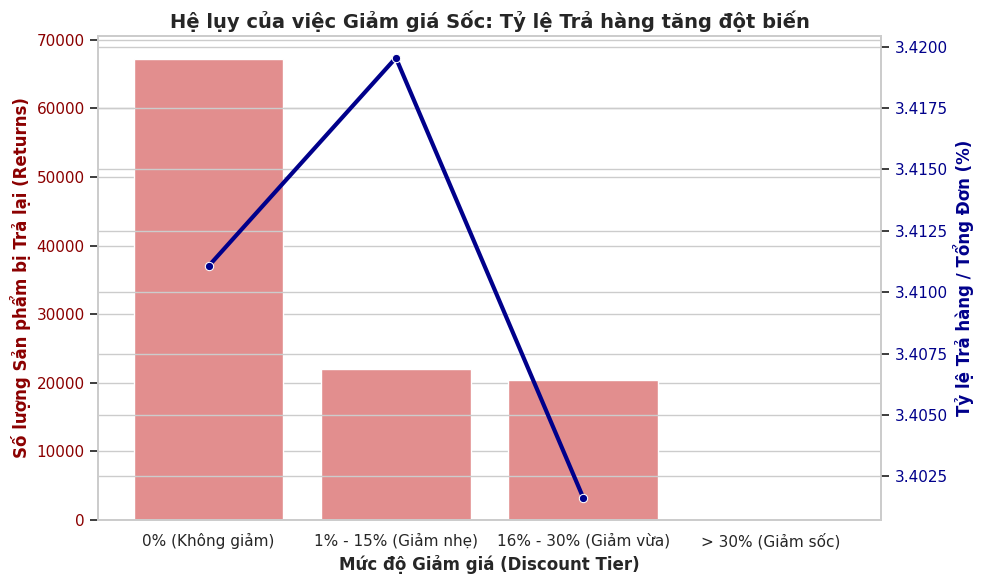

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

base_path = "/kaggle/input/datasets/chauhaiham/datathon-2026/"

# Giả định bạn đã chạy biến BASE_PATH ở trên rồi
# orders = pd.read_csv(BASE_PATH + 'orders.csv')
# order_items = pd.read_csv(BASE_PATH + 'order_items.csv')
# returns = pd.read_csv(BASE_PATH + 'returns.csv')

# 1. Tính toán Tỷ lệ giảm giá (Discount Percentage) cho mỗi dòng sản phẩm
order_items['total_value'] = order_items['unit_price'] * order_items['quantity']
order_items['discount_pct'] = (order_items['discount_amount'] / order_items['total_value']).fillna(0)

# Phân nhóm mức độ giảm giá (Binning)
bins = [-np.inf, 0, 0.15, 0.30, np.inf]
labels = ['0% (Không giảm)', '1% - 15% (Giảm nhẹ)', '16% - 30% (Giảm vừa)', '> 30% (Giảm sốc)']
order_items['discount_tier'] = pd.cut(order_items['discount_pct'], bins=bins, labels=labels)

# 2. Gộp với bảng returns để xem món nào bị trả lại
# Dùng left join vì không phải món nào cũng bị trả
df_returns_analysis = pd.merge(order_items, returns, on=['order_id', 'product_id'], how='left')

# Tạo cờ (flag) xem sản phẩm có bị trả không
df_returns_analysis['is_returned'] = df_returns_analysis['return_id'].notnull().astype(int)

# 3. Tính tỷ lệ trả hàng và phân bố lý do trả hàng theo từng nhóm giảm giá
return_summary = df_returns_analysis.groupby('discount_tier').agg(
    total_items=('quantity', 'sum'),
    returned_items=('return_quantity', 'sum')
).reset_index()
return_summary['return_rate'] = (return_summary['returned_items'] / return_summary['total_items']) * 100

# 4. Trực quan hoá: Biểu đồ Cột kết hợp Đường (Bar & Line Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Trục 1: Cột hiển thị số lượng sản phẩm bị trả lại
sns.barplot(data=return_summary, x='discount_tier', y='returned_items', color='lightcoral', ax=ax1)
ax1.set_ylabel('Số lượng Sản phẩm bị Trả lại (Returns)', color='darkred', fontweight='bold')
ax1.set_xlabel('Mức độ Giảm giá (Discount Tier)', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='darkred')

# Trục 2: Đường hiển thị Tỷ lệ trả hàng (%)
ax2 = ax1.twinx()
sns.lineplot(data=return_summary, x='discount_tier', y='return_rate', color='darkblue', marker='o', linewidth=3, ax=ax2)
ax2.set_ylabel('Tỷ lệ Trả hàng / Tổng Đơn (%)', color='darkblue', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='darkblue')

plt.title('Hệ lụy của việc Giảm giá Sốc: Tỷ lệ Trả hàng tăng đột biến', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('insight_return_rate.pdf')
plt.show()

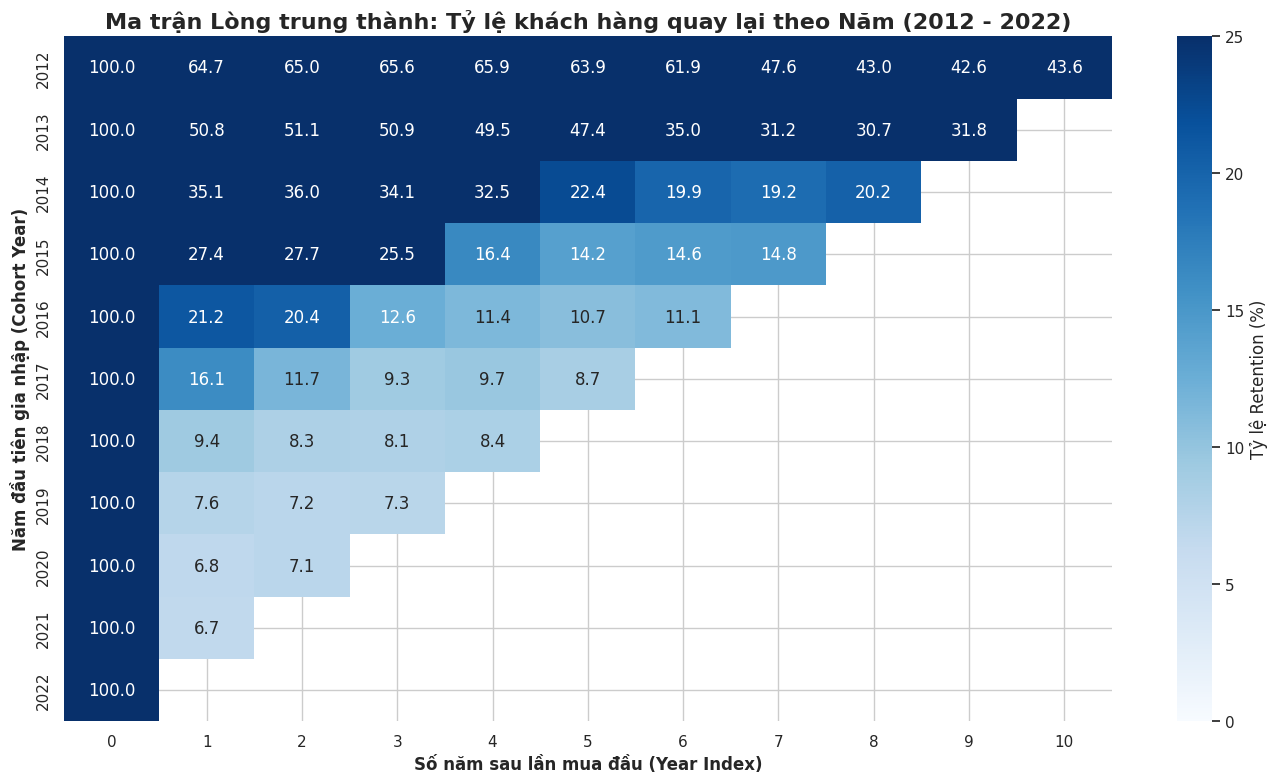

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
# orders = pd.read_csv(BASE_PATH + 'orders.csv')

# Chuyển đổi ngày tháng
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['order_year'] = orders['order_date'].dt.year

# Xác định Năm đầu tiên mua hàng của mỗi khách (Cohort Year)
orders['cohort_year'] = orders.groupby('customer_id')['order_year'].transform('min')

# 2. Tính khoảng cách năm (Year Index)
# Index 0: Năm đầu tiên, Index 1: Quay lại sau 1 năm...
orders['year_index'] = orders['order_year'] - orders['cohort_year']

# 3. Tạo ma trận Retention
cohort_data = orders.groupby(['cohort_year', 'year_index'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_year', columns='year_index', values='customer_id')

# Tính tỷ lệ % Retention
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

# 4. Trực quan hóa Heatmap
plt.figure(figsize=(14, 8))
plt.title('Ma trận Lòng trung thành: Tỷ lệ khách hàng quay lại theo Năm (2012 - 2022)', fontsize=16, fontweight='bold')

sns.heatmap(data=retention_matrix, 
            annot=True, 
            fmt='.1f', 
            cmap='Blues', 
            vmin=0, 
            vmax=25, # Thường retention theo năm sẽ thấp hơn theo tháng nên set max 25-30% để màu rõ hơn
            cbar_kws={'label': 'Tỷ lệ Retention (%)'})

plt.ylabel('Năm đầu tiên gia nhập (Cohort Year)', fontweight='bold')
plt.xlabel('Số năm sau lần mua đầu (Year Index)', fontweight='bold')
plt.tight_layout()
plt.savefig('yearly_cohort_retention.pdf')
plt.show()

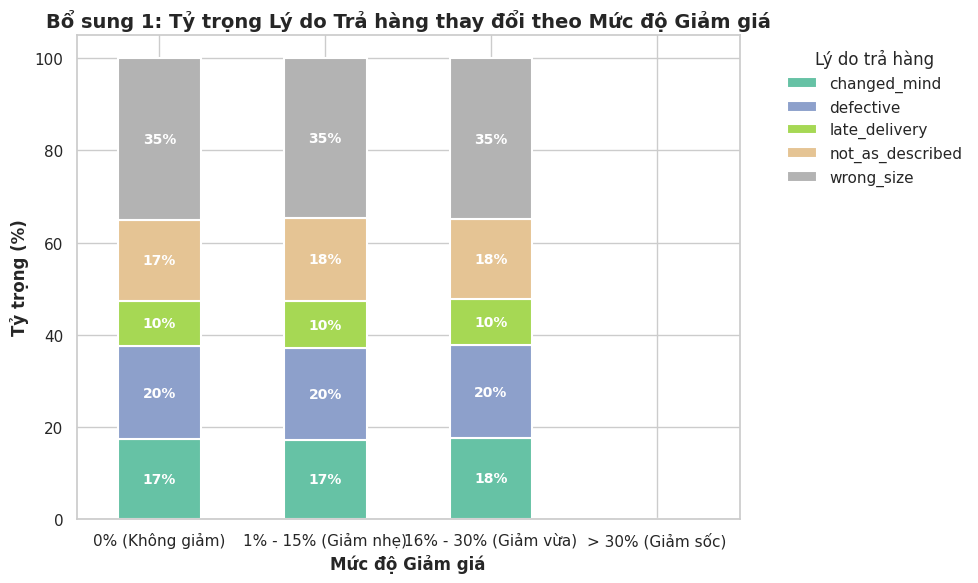

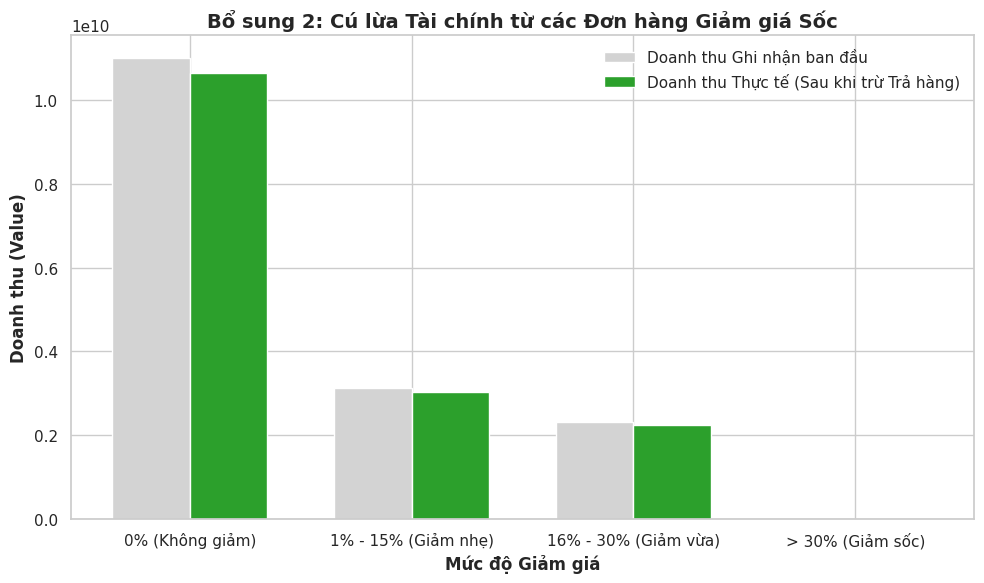

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Giả định df_returns_analysis đã được tạo từ đoạn code Ý tưởng 1 trước đó
# Nếu chưa, bạn cần chạy lại phần chia bins 'discount_tier' nhé!

# ==========================================
# BIỂU ĐỒ BỔ SUNG 1: LÝ DO TRẢ HÀNG (100% STACKED BAR)
# ==========================================

# Lọc ra những đơn có trả hàng
df_only_returns = df_returns_analysis[df_returns_analysis['is_returned'] == 1]

# Đếm số lượng lý do trả hàng theo từng mức giảm giá
reason_counts = df_only_returns.groupby(['discount_tier', 'return_reason']).size().unstack(fill_value=0)

# Chuyển đổi thành tỷ lệ % (Tổng mỗi cột = 100%)
reason_pct = reason_counts.divide(reason_counts.sum(axis=1), axis=0) * 100

# Vẽ biểu đồ
ax1 = reason_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', edgecolor='white', linewidth=1.5)
plt.title('Bổ sung 1: Tỷ trọng Lý do Trả hàng thay đổi theo Mức độ Giảm giá', fontsize=14, fontweight='bold')
plt.xlabel('Mức độ Giảm giá', fontweight='bold')
plt.ylabel('Tỷ trọng (%)', fontweight='bold')
plt.legend(title='Lý do trả hàng', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Thêm % vào giữa các khối màu
for c in ax1.containers:
    labels = [f'{w:.0f}%' if (w := v.get_height()) > 5 else '' for v in c]
    ax1.bar_label(c, labels=labels, label_type='center', fontsize=10, color='white', weight='bold')

plt.tight_layout()
plt.savefig('insight_return_reasons_stacked.pdf')
plt.show()


# ==========================================
# BIỂU ĐỒ BỔ SUNG 2: DOANH THU ẢO VS THỰC TẾ
# ==========================================

# Tính Doanh thu ban đầu và Số tiền hoàn lại
financial_impact = df_returns_analysis.groupby('discount_tier').agg(
    gross_revenue=('total_value', 'sum'),
    total_refund=('refund_amount', 'sum')
).reset_index()

# Tính Doanh thu thực tế (Net Revenue)
financial_impact['net_revenue'] = financial_impact['gross_revenue'] - financial_impact['total_refund']

# Vẽ biểu đồ cột kép
fig, ax2 = plt.subplots(figsize=(10, 6))

x = np.arange(len(financial_impact['discount_tier']))
width = 0.35

ax2.bar(x - width/2, financial_impact['gross_revenue'], width, label='Doanh thu Ghi nhận ban đầu', color='lightgray')
ax2.bar(x + width/2, financial_impact['net_revenue'], width, label='Doanh thu Thực tế (Sau khi trừ Trả hàng)', color='tab:green')

ax2.set_title('Bổ sung 2: Cú lừa Tài chính từ các Đơn hàng Giảm giá Sốc', fontsize=14, fontweight='bold')
ax2.set_xlabel('Mức độ Giảm giá', fontweight='bold')
ax2.set_ylabel('Doanh thu (Value)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(financial_impact['discount_tier'])
ax2.legend()

plt.tight_layout()
plt.savefig('insight_financial_illusion.pdf')
plt.show()